Parkinson’s Disease (PD) is a degenerative neurological disorder marked by decreased dopamine levels in the brain. It manifests itself through a deterioration of movement, including the presence of tremors and stiffness. There is commonly a marked effect on speech, including dysarthria (difficulty articulating sounds), hypophonia (lowered volume), and monotone (reduced pitch range). Additionally, cognitive impairments and changes in mood can occur, and risk of dementia is increased.

Traditional diagnosis of Parkinson’s Disease involves a clinician taking a neurological history of the patient and observing motor skills in various situations. Since there is no definitive laboratory test to diagnose PD, diagnosis is often difficult, particularly in the early stages when motor effects are not yet severe. Monitoring progression of the disease over time requires repeated clinic visits by the patient. An effective screening process, particularly one that doesn’t require a clinic visit, would be beneficial. Since PD patients exhibit characteristic vocal features, voice recordings are a useful and non-invasive tool for diagnosis. If machine learning algorithms could be applied to a voice recording dataset to accurately diagnosis PD, this would be an effective screening step prior to an appointment with a clinician.

The data & attributes information for this project is available at https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/ (Links to an external site.)Links to an external site. The data consists of those diagnosed with Parkinson Disease and those who do not.

Steps to be followed:

Use a Python notebook & Load the dataset
It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)
Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)
Split the dataset into training and test set in the ratio of 70:30 (Training:Test).
Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)
Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)
Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points) 
Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)

**Question 1: Use a Python notebook & Load the dataset It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset.**

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

In [54]:
pks_df = pd.read_csv('parkinsons.data')

In [10]:
pks_df.head().T

,0,1,2,3,4
name,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3,phon_R01_S01_4,phon_R01_S01_5
MDVP:Fo(Hz),119.992,122.4,116.682,116.676,116.014
MDVP:Fhi(Hz),157.302,148.65,131.111,137.871,141.781
MDVP:Flo(Hz),74.997,113.819,111.555,111.366,110.655
MDVP:Jitter(%),0.00784,0.00968,0.0105,0.00997,0.01284
MDVP:Jitter(Abs),7e-05,8e-05,9e-05,9e-05,0.00011
MDVP:RAP,0.0037,0.00465,0.00544,0.00502,0.00655
MDVP:PPQ,0.00554,0.00696,0.00781,0.00698,0.00908
Jitter:DDP,0.01109,0.01394,0.01633,0.01505,0.01966
MDVP:Shimmer,0.04374,0.06134,0.05233,0.05492,0.06425


In [4]:
pks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [7]:
pks_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [16]:
pks_df['status'].value_counts()
#This is the target column 1 -> Parkinson and 2-> No Parkinson

1    147
0     48
Name: status, dtype: int64

In [15]:
pks_df.shape

(195, 24)

**Question 2: Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)** 

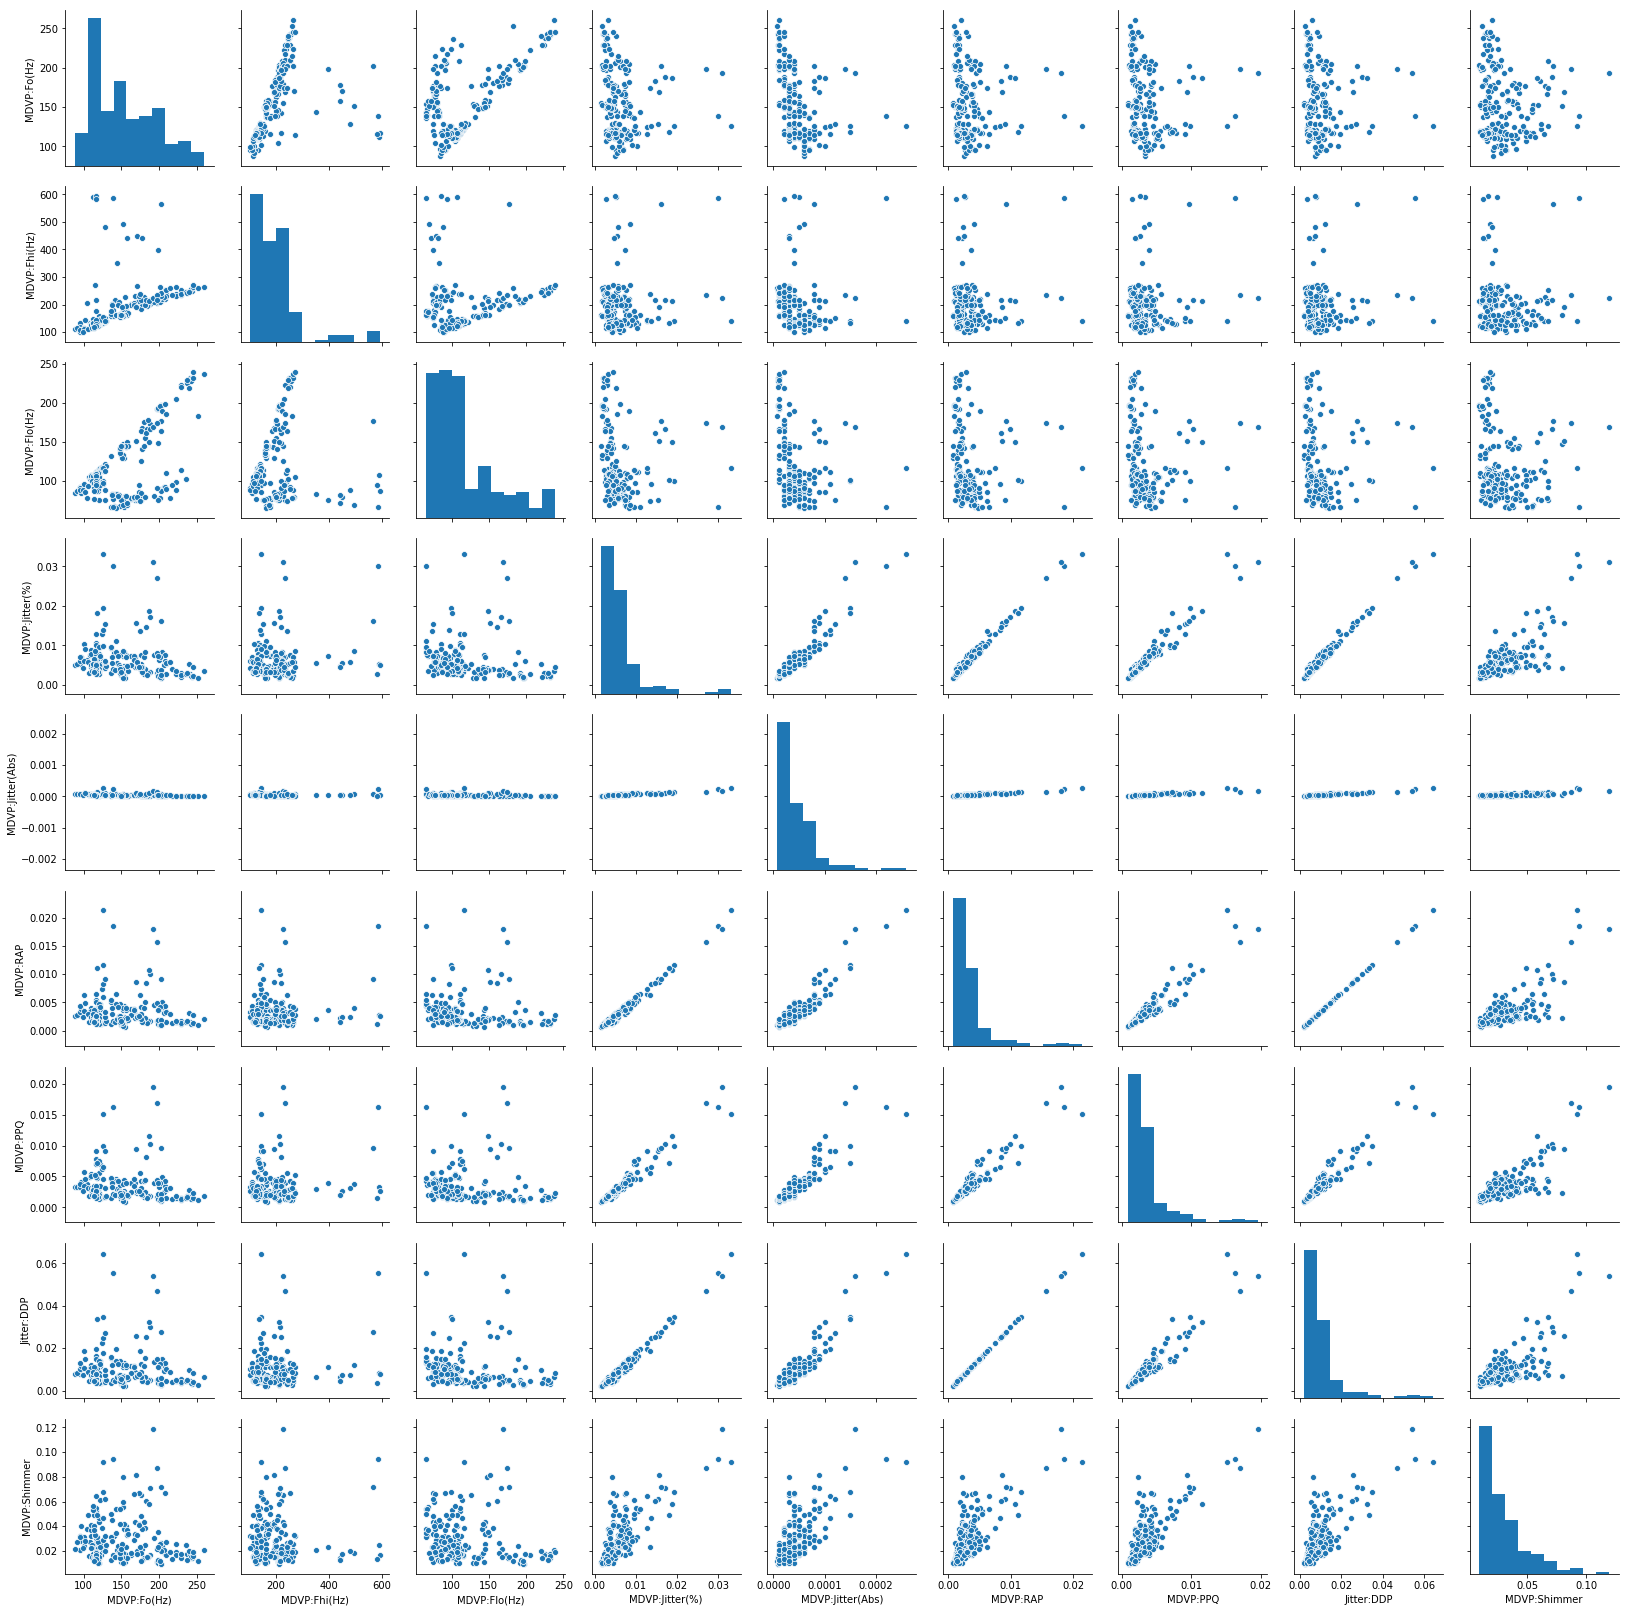

In [24]:
sns.pairplot(pks_df.iloc[:,0:10])

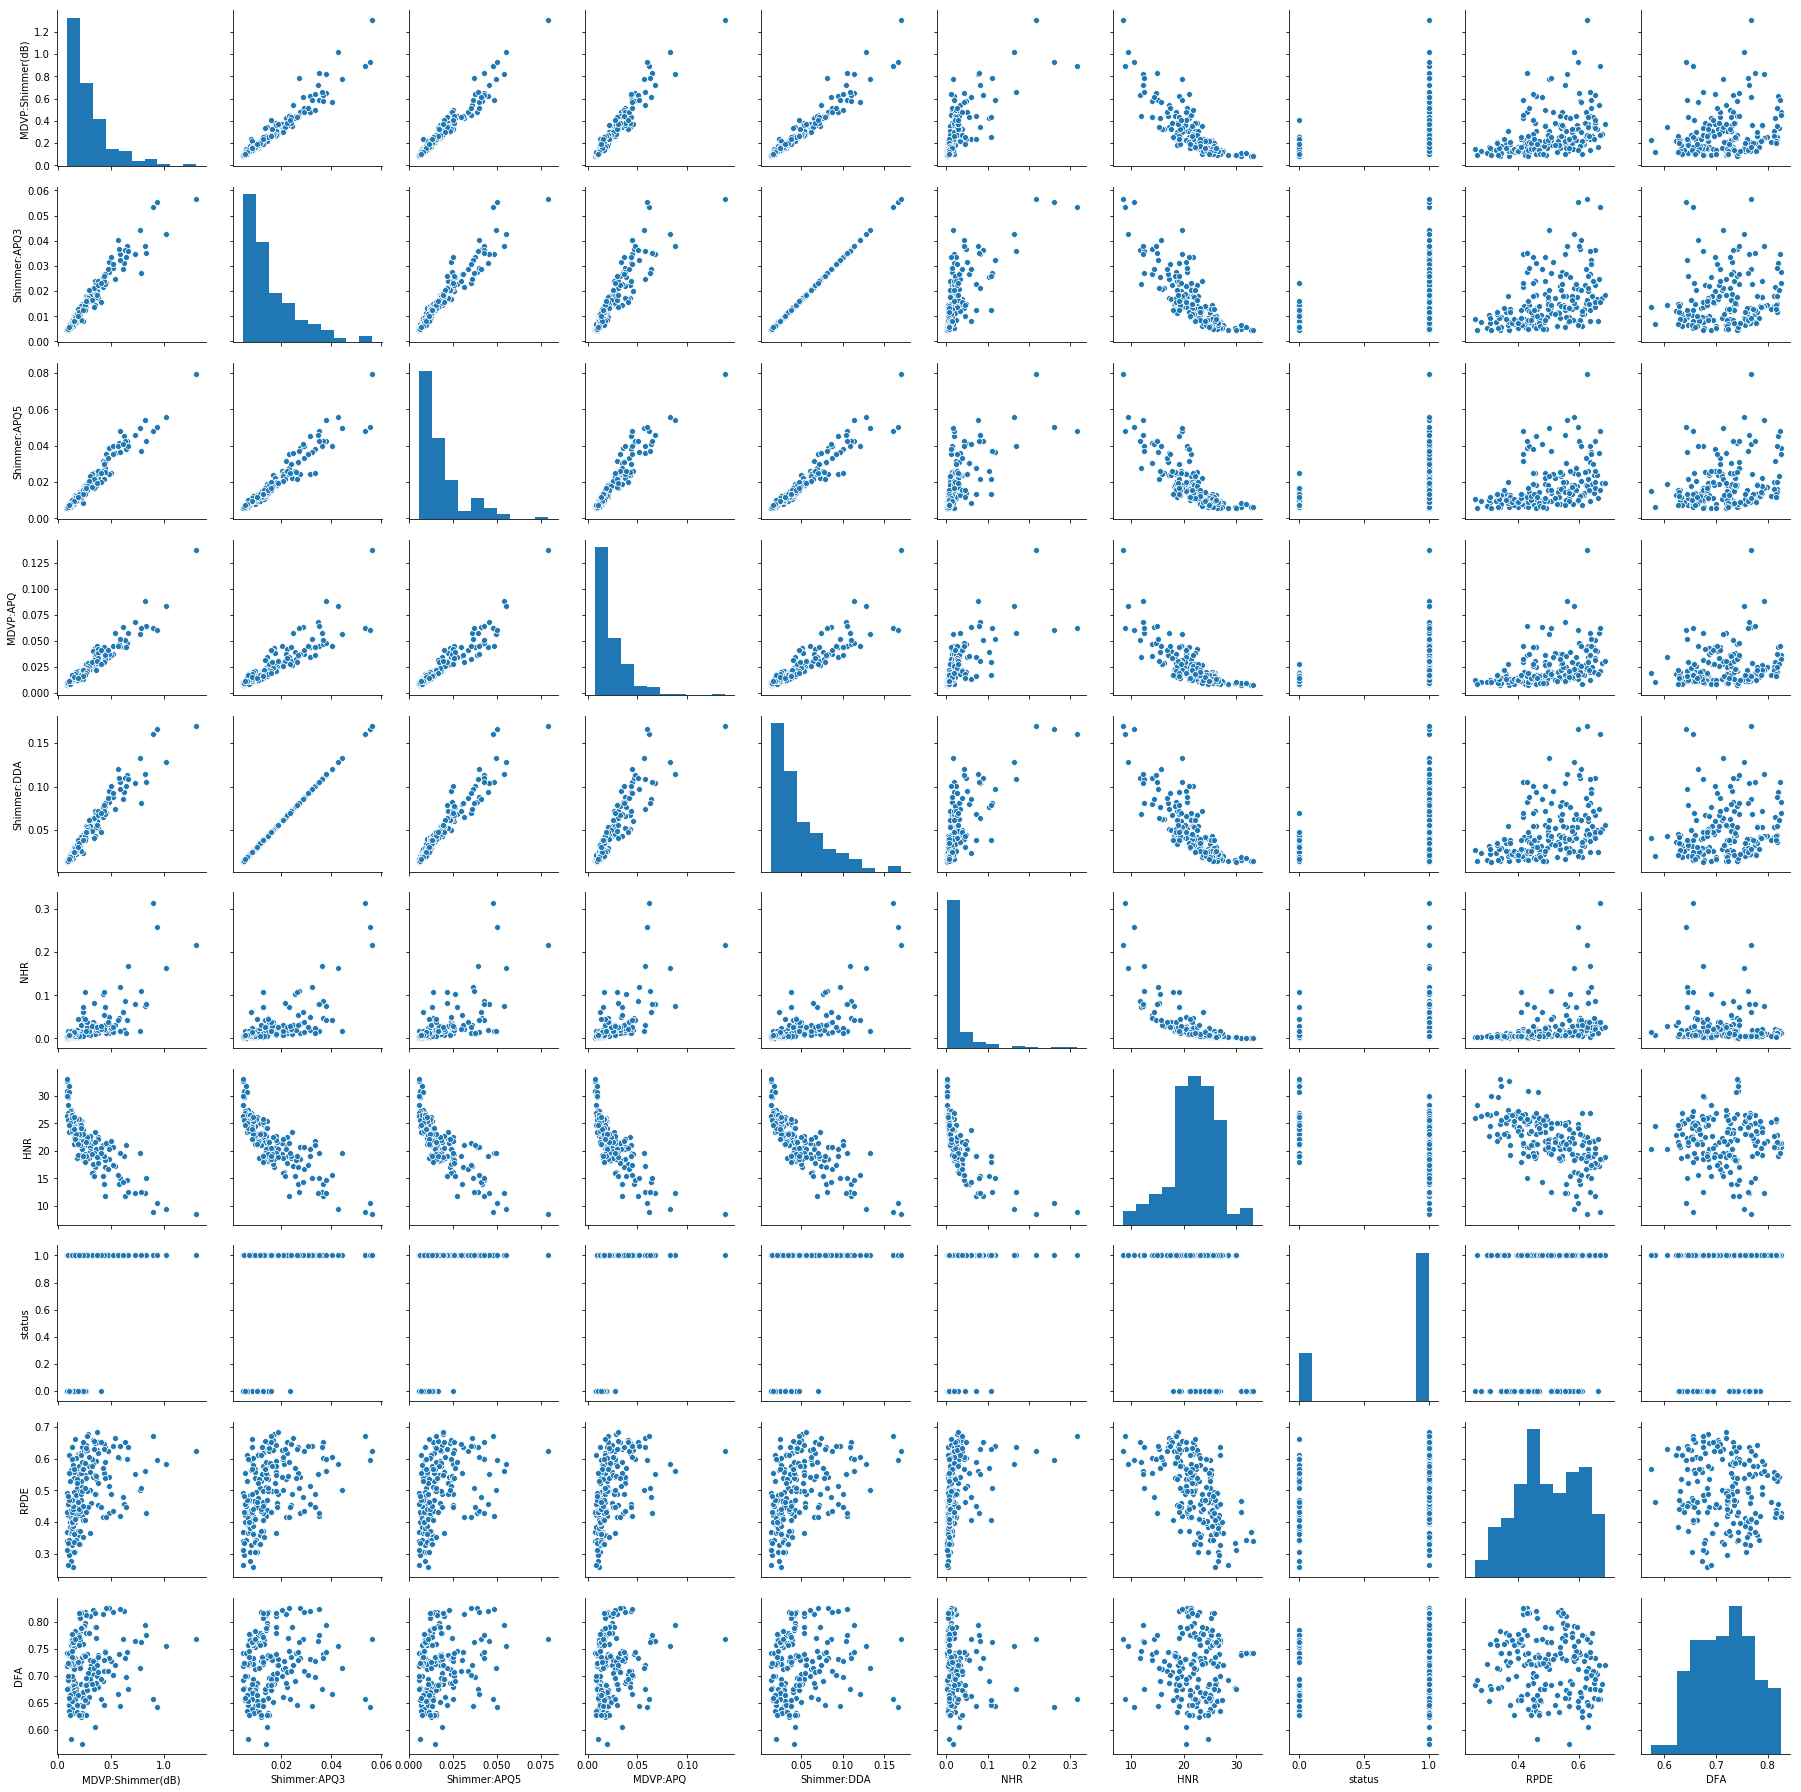

In [28]:
sns.pairplot(pks_df.iloc[:,10:20])

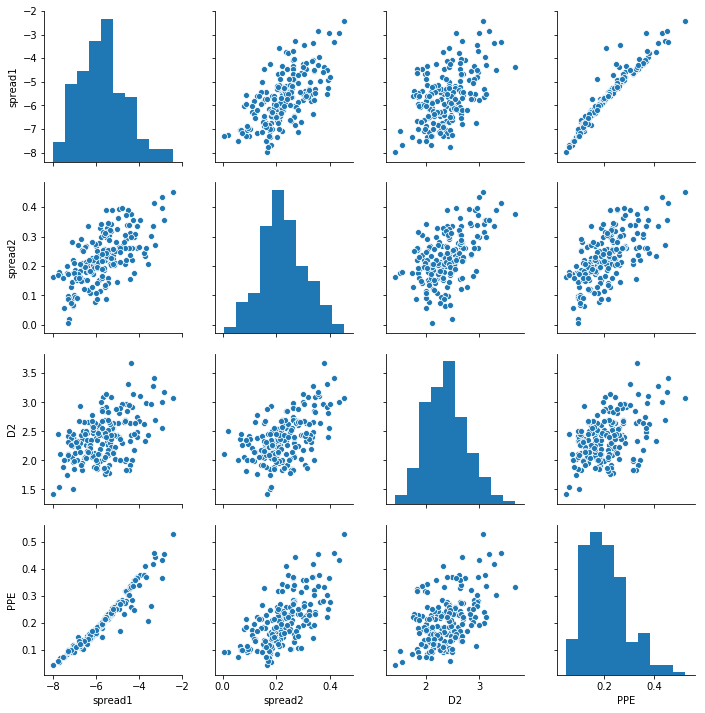

In [29]:
sns.pairplot(pks_df.iloc[:,20:27])

In [26]:
pks_df.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

# Univariate Analysis:
Name - Object variable with patient name and record number<br>
MDVP:Fo(Hz) - Average vocal fundamental frequency - Right tailed distribution. Mean of 152.44 Hz<br>
MDVP:Fhi(Hz) - Maximum vocal fundamental frequency - Right tailed distribution. Mean of 197.1 Hz <br>
MDVP:Flo(Hz) - Minimum vocal fundamental frequency - Right tailed distribution. Mean of 116.32 Hz<br>
MDVP:Jitter(%) - One of the measures of variation in fundamental frequency - Right tailed distribution with quite a few outliers. Mean of 0.0062<br>
MDVP:Jitter(Abs)  - One of the measures of variation in fundamental frequency - Right tailed distribution with quite a few outliers. Mean of 0.000044<br>
MDVP:RAP - One of the measures of variation in fundamental frequency - Right tailed distribution with quite a few outliers. Mean of 0.003306<br>
MDVP:PPQ  - One of the measures of variation in fundamental frequency - Right tailed distribution with quite a few outliers. Mean of 0.003446<br>
Jitter:DDP - One of the measures of variation in fundamental frequency - Right tailed distribution with quite a few outliers. Mean of 0.009920<br>
MDVP:Shimmer - One of the measures of variation in Amplitude - Right tailed distribution with quite a few outliers. Mean of 0.029709<br>
MDVP:Shimmer(dB) - One of the measures of variation in Amplitude - Right tailed distribution with quite a few outliers. Mean of 0.282251<br>
Shimmer:APQ3 - One of the measures of variation in Amplitude - Right tailed distribution with quite a few outliers. Mean of 0.015664<br>
Shimmer:APQ5 - One of the measures of variation in Amplitude - Right tailed distribution with quite a few outliers. Mean of 0.017878<br>
MDVP:APQ - One of the measures of variation in Amplitude - Right tailed distribution with quite a few outliers. Mean of 0.024081<br>
Shimmer:DDA - One of the measures of variation in Amplitude - Right tailed distribution with quite a few outliers. Mean of 0.046993<br>
NHR - Measure of ratio of noise to tonal components in the voice - Right tailed distribution with outliers. Mean of 0.0248<br>
HNR - Measure of ratio of noise to tonal components in the voice - Normal distributed data. Mean of 21.885974<br>
status - 0 for No Parkinsons and 1 for Parkinson. Has a frequency of 0-48 and 1-147<br>
RPDE - Nonlinear dynamical complexity measures - Normal distributed data. Mean of 0.4985<br>
DFA - Signal fractal scaling exponent - Normal distributed data (Slightly left tailed). Mean of 0.718099<br>
spread1 - Nonlinear measures of fundamental frequency variation - Normally distributed. Mean of 5.684397<br>
spread2 - Nonlinear measures of fundamental frequency variation - Normally distributed. Mean of 0.2265<br>
D2 - Nonlinear dynamical complexity measures - Normal distributed data. Mean of 2.381826<br>
PPE - Nonlinear measures of fundamental frequency variation - Normal distriobuted. Mean of 0.2065<br>

# Bivariate Analysis:<br>
Drop in vocal frequencies is a strong indicator of positive parkinsons.<br>
Higher variation in fundamental frequency strongly correlates to a positive parkinsons diagnosis.<br>
Higher variation in amplitude strongly correlates to a positive parkinsons diagnosis.<br>
Spread1 Spread2 and PPE have a strong correlation to output variable<br>
**Note: Above observations are based on box plots and correlation matrix below**


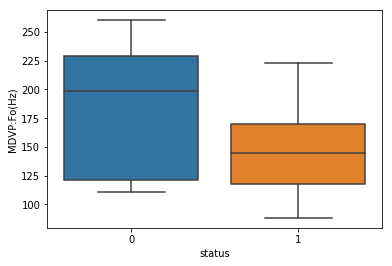

In [30]:
sns.boxplot(x='status',y='MDVP:Fo(Hz)', data=pks_df)

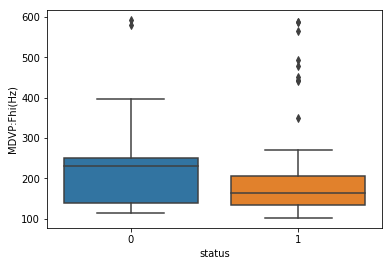

In [31]:
sns.boxplot(x='status',y='MDVP:Fhi(Hz)', data=pks_df)

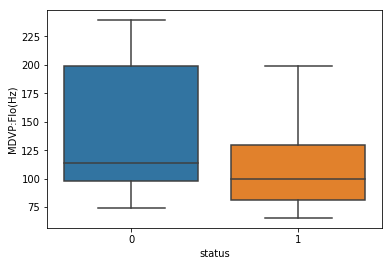

In [32]:
sns.boxplot(x='status',y='MDVP:Flo(Hz)', data=pks_df)

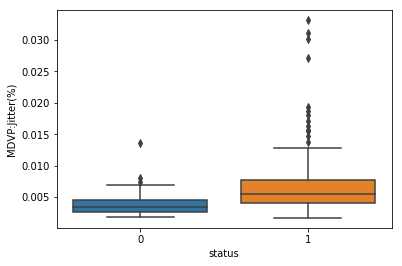

In [33]:
sns.boxplot(x='status',y='MDVP:Jitter(%)', data=pks_df)

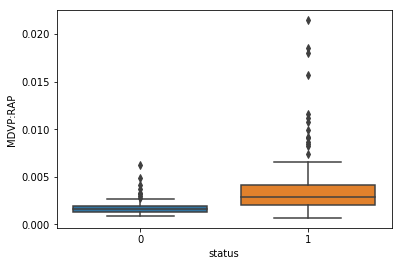

In [35]:
sns.boxplot(x='status',y='MDVP:RAP', data=pks_df)

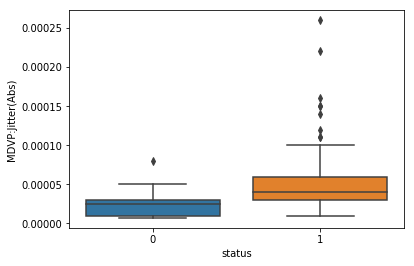

In [34]:
sns.boxplot(x='status',y='MDVP:Jitter(Abs)', data=pks_df)

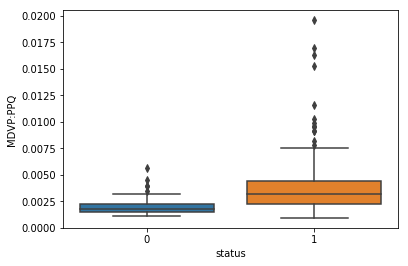

In [36]:
sns.boxplot(x='status',y='MDVP:PPQ', data=pks_df)

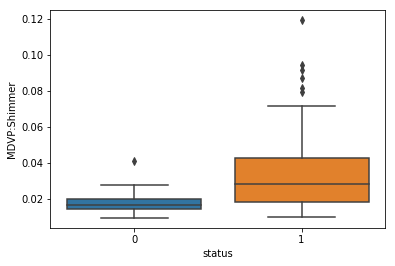

In [37]:
sns.boxplot(x='status',y='MDVP:Shimmer', data=pks_df)

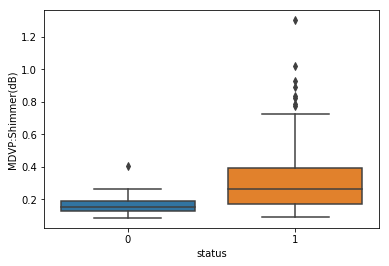

In [38]:
sns.boxplot(x='status',y='MDVP:Shimmer(dB)', data=pks_df)

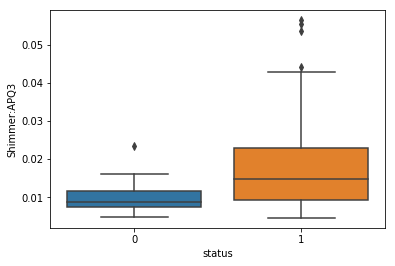

In [39]:
sns.boxplot(x='status',y='Shimmer:APQ3', data=pks_df)

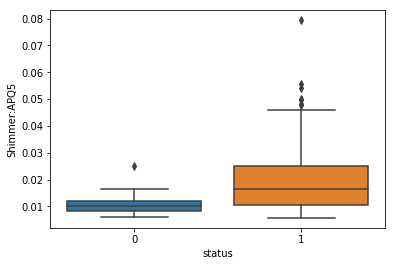

In [40]:
sns.boxplot(x='status',y='Shimmer:APQ5', data=pks_df)

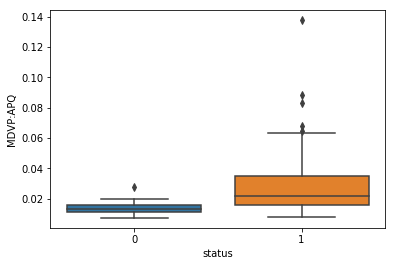

In [41]:
sns.boxplot(x='status',y='MDVP:APQ', data=pks_df)

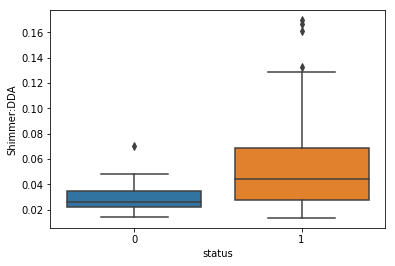

In [42]:
sns.boxplot(x='status',y='Shimmer:DDA', data=pks_df)

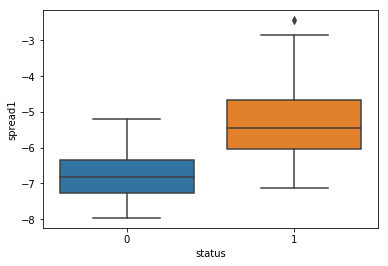

In [44]:
sns.boxplot(x='status',y='spread1', data=pks_df)

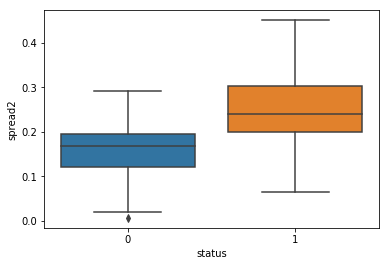

In [45]:
sns.boxplot(x='status',y='spread2', data=pks_df)

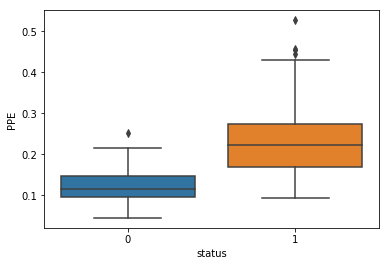

In [46]:
sns.boxplot(x='status',y='PPE', data=pks_df)

In [43]:
pks_df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383535,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.166136,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.380200,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.278220,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.338653,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.266668,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.288698,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.266646,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.367430,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.350697,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058


**Question 3: Split the dataset into training and test set in the ratio of 70:30 (Training:Test).
Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)**

In [55]:
pks_df['status'] = pks_df['status'].replace({0: 'Healthy', 1: 'Parkinson'})

In [56]:
pks_df['status'].tail(20)

175      Healthy
176      Healthy
177    Parkinson
178    Parkinson
179    Parkinson
180    Parkinson
181    Parkinson
182    Parkinson
183      Healthy
184      Healthy
185      Healthy
186      Healthy
187      Healthy
188      Healthy
189      Healthy
190      Healthy
191      Healthy
192      Healthy
193      Healthy
194      Healthy
Name: status, dtype: object

In [57]:
#Define X and Y
X=pks_df.drop(['status', 'name'], axis=1)
Y=pks_df['status']

In [62]:
Y

0      Parkinson
1      Parkinson
2      Parkinson
3      Parkinson
4      Parkinson
5      Parkinson
6      Parkinson
7      Parkinson
8      Parkinson
9      Parkinson
10     Parkinson
11     Parkinson
12     Parkinson
13     Parkinson
14     Parkinson
15     Parkinson
16     Parkinson
17     Parkinson
18     Parkinson
19     Parkinson
20     Parkinson
21     Parkinson
22     Parkinson
23     Parkinson
24     Parkinson
25     Parkinson
26     Parkinson
27     Parkinson
28     Parkinson
29     Parkinson
         ...    
165      Healthy
166      Healthy
167      Healthy
168      Healthy
169      Healthy
170      Healthy
171      Healthy
172      Healthy
173      Healthy
174      Healthy
175      Healthy
176      Healthy
177    Parkinson
178    Parkinson
179    Parkinson
180    Parkinson
181    Parkinson
182    Parkinson
183      Healthy
184      Healthy
185      Healthy
186      Healthy
187      Healthy
188      Healthy
189      Healthy
190      Healthy
191      Healthy
192      Healt

In [65]:
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.3,random_state=0)

In [66]:
Xtrain=np.array(xtrain)
Ytrain=np.array(ytrain)

In [67]:
Xtest=np.array(xtest)
Ytest=np.array(ytest)

In [117]:
model1=DecisionTreeClassifier(random_state=0,criterion='entropy')
model1.fit(Xtrain,Ytrain)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

**Question 4: Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)**

In [118]:
ypred1=model1.predict(Xtest)

In [119]:
acc1=metrics.accuracy_score(Ytest,ypred1)
print(acc1)

0.8983050847457628


In [120]:
cm=metrics.confusion_matrix(Ytest,ypred1)
print(cm)

[[13  0]
 [ 6 40]]


In [121]:
ypred1

array(['Healthy', 'Parkinson', 'Healthy', 'Parkinson', 'Healthy',
       'Parkinson', 'Healthy', 'Healthy', 'Parkinson', 'Parkinson',
       'Healthy', 'Parkinson', 'Healthy', 'Parkinson', 'Healthy',
       'Parkinson', 'Healthy', 'Healthy', 'Healthy', 'Parkinson',
       'Parkinson', 'Healthy', 'Parkinson', 'Parkinson', 'Healthy',
       'Parkinson', 'Parkinson', 'Healthy', 'Healthy', 'Healthy',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Healthy',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson',
       'Healthy', 'Parkinson', 'Healthy', 'Parkinson', 'Parkinson',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson'], dtype=object)

In [122]:
pd.crosstab(Ytest,ypred1)

col_0,Healthy,Parkinson
row_0,,
Healthy,13,0
Parkinson,6,40


**Question 5: Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points)**

In [134]:
#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,5),'min_samples_leaf':np.arange(1,5)}
GS=GridSearchCV(model1,parameter)
GS.fit(X,Y)

/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)


GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4]), 'min_samples_leaf': array([1, 2, 3, 4])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [135]:
gs_pred=GS.predict(Xtest)

In [136]:
metrics.accuracy_score(Ytest,gs_pred)

1.0

In [140]:
GS.best_params_

{'max_depth': 4, 'min_samples_leaf': 1}

array(['Parkinson', 'Parkinson', 'Healthy', 'Parkinson', 'Healthy',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Healthy',
       'Parkinson', 'Parkinson', 'Healthy', 'Healthy', 'Parkinson',
       'Parkinson', 'Healthy', 'Parkinson', 'Parkinson', 'Healthy',
       'Parkinson', 'Parkinson', 'Healthy', 'Healthy', 'Healthy',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Healthy',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson',
       'Healthy', 'Parkinson', 'Healthy', 'Parkinson', 'Parkinson',
       'Parkinson', 'Parkinson', 'Parkinson', 'Parkinson'], dtype=object)

In [139]:
pd.crosstab(ytest,gs_pred)

col_0,Healthy,Parkinson
status,,
Healthy,13,0
Parkinson,0,46


In [143]:
cr = metrics.classification_report(Ytest,gs_pred)
print(cr)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        13
   Parkinson       1.00      1.00      1.00        46

   micro avg       1.00      1.00      1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59



# Regularization using GridSearchCV<br>
**By varying max_depth from 1-5 and min_samples_leaf from 1-5, we used grid search for decision tree**<br>
**According to greid search, at max_depth=4 and min_samples_leaf=1, we get accuracy of 100% with recall  and precision of 1**<br>
**Model is highly overfit as its a fully grown decision tree**





**Question 6: Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)**

In [145]:
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',max_depth=4,random_state=0 )

In [146]:
Rf_model.fit(Xtrain, Ytrain)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=51, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

In [147]:
y_predict_Rf=Rf_model.predict(Xtest)

In [148]:
Rf_acc=metrics.accuracy_score(ytest,y_predict_Rf)
print(Rf_acc)

0.9152542372881356


In [ ]:
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',max_depth=4,random_state=0 )

In [149]:
parameter={'n_estimators':np.arange(3,101,2)}
GS=GridSearchCV(Rf_model,parameter)
GS.fit(X,Y)

/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)


GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=51, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35,
       37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69,
       71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [150]:
gs_pred=GS.predict(Xtest)

In [151]:
metrics.accuracy_score(Ytest,gs_pred)

0.9830508474576272

In [152]:
GS.best_params_

{'n_estimators': 5}

In [153]:
pd.crosstab(ytest,gs_pred)

col_0,Healthy,Parkinson
status,,
Healthy,12,1
Parkinson,0,46


In [154]:
cr = metrics.classification_report(Ytest,gs_pred)
print(cr)

              precision    recall  f1-score   support

     Healthy       1.00      0.92      0.96        13
   Parkinson       0.98      1.00      0.99        46

   micro avg       0.98      0.98      0.98        59
   macro avg       0.99      0.96      0.97        59
weighted avg       0.98      0.98      0.98        59



**Optimal number of trees is 5 where we get the best results with accuracy of 0.983 at a recall of 1 for Parkinson**